In [ ]:
# DuckDB: an in-process SQL engine, good for querying CSVs directly without a separate database server
import duckdb

In [ ]:
# Opens (or creates) a local database file to hold the loaded tables
con = duckdb.connect("olist.duckdb")

In [ ]:
# Names of the raw Olist CSVs to load, one table per file
tables = [
    "olist_customers_dataset",
    "olist_geolocation_dataset",
    "olist_order_items_dataset",
    "olist_order_payments_dataset",
    "olist_order_reviews_dataset",
    "olist_orders_dataset",
    "olist_products_dataset",
    "olist_sellers_dataset",
    "product_category_name_translation",
]

In [ ]:
# Load each CSV into its own table, replacing it if it already exists
for t in tables:
    con.execute(f"""
        CREATE OR REPLACE TABLE {t} AS
        SELECT * FROM read_csv_auto('../data/olist/{t}.csv')
    """)

In [ ]:
# Confirm all 9 tables loaded successfully
con.sql("SHOW TABLES")

┌───────────────────────────────────┐
│               name                │
│              varchar              │
├───────────────────────────────────┤
│ olist_customers_dataset           │
│ olist_geolocation_dataset         │
│ olist_order_items_dataset         │
│ olist_order_payments_dataset      │
│ olist_order_reviews_dataset       │
│ olist_orders_dataset              │
│ olist_products_dataset            │
│ olist_sellers_dataset             │
│ orders_clean                      │
│ product_category_name_translation │
└───────────────────────────────────┘
               10 rows             

In [ ]:
# Row counts per table, a quick sanity check against the known Olist dataset sizes
for t in tables:
    count = con.sql(f"SELECT COUNT(*) AS n FROM {t}").fetchone()[0]
    print(f"{t}: {count:,} rows")

olist_customers_dataset: 99,441 rows
olist_geolocation_dataset: 1,000,163 rows
olist_order_items_dataset: 112,650 rows
olist_order_payments_dataset: 103,886 rows
olist_order_reviews_dataset: 99,224 rows
olist_orders_dataset: 99,441 rows
olist_products_dataset: 32,951 rows
olist_sellers_dataset: 3,095 rows
product_category_name_translation: 71 rows


In [ ]:
# Check column names and types before writing queries against this table
con.sql("DESCRIBE olist_orders_dataset")

┌───────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│          column_name          │ column_type │  null   │   key   │ default │  extra  │
│            varchar            │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ order_id                      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ customer_id                   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ order_status                  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ order_purchase_timestamp      │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ order_approved_at             │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ order_delivered_carrier_date  │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ order_delivered_customer_date │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ order_estimated_delivery_date 

In [9]:
# Get a quick picture of the orders table: total rows, how many are missing
# a delivery date, and how many are actually marked delivered.
con.sql("""
    SELECT
        COUNT(*) AS total_orders,
        COUNT(*) FILTER (WHERE order_delivered_customer_date IS NULL) AS missing_delivered_date,
        COUNT(*) FILTER (WHERE order_estimated_delivery_date IS NULL) AS missing_estimated_date,
        COUNT(*) FILTER (WHERE order_status = 'delivered') AS status_delivered
    FROM olist_orders_dataset
""")


┌──────────────┬────────────────────────┬────────────────────────┬──────────────────┐
│ total_orders │ missing_delivered_date │ missing_estimated_date │ status_delivered │
│    int64     │         int64          │         int64          │      int64       │
├──────────────┼────────────────────────┼────────────────────────┼──────────────────┤
│        99441 │                   2965 │                      0 │            96478 │
└──────────────┴────────────────────────┴────────────────────────┴──────────────────┘

In [10]:
# Naive math predicted only ~2 mismatched rows, but that assumed status and
# delivery date always agree. Checking directly: find orders marked delivered
# that still have no delivery date logged.
con.sql("""
    SELECT order_id, order_status, order_purchase_timestamp,
           order_delivered_customer_date, order_estimated_delivery_date
    FROM olist_orders_dataset
    WHERE order_status = 'delivered' AND order_delivered_customer_date IS NULL
""")

┌──────────────────────────────────┬──────────────┬──────────────────────────┬───────────────────────────────┬───────────────────────────────┐
│             order_id             │ order_status │ order_purchase_timestamp │ order_delivered_customer_date │ order_estimated_delivery_date │
│             varchar              │   varchar    │        timestamp         │           timestamp           │           timestamp           │
├──────────────────────────────────┼──────────────┼──────────────────────────┼───────────────────────────────┼───────────────────────────────┤
│ 2d1e2d5bf4dc7227b3bfebb81328c15f │ delivered    │ 2017-11-28 17:44:07      │ NULL                          │ 2017-12-18 00:00:00           │
│ f5dd62b788049ad9fc0526e3ad11a097 │ delivered    │ 2018-06-20 06:58:43      │ NULL                          │ 2018-07-16 00:00:00           │
│ 2ebdfc4f15f23b91474edf87475f108e │ delivered    │ 2018-07-01 17:05:11      │ NULL                          │ 2018-07-30 00:00:00           │

In [11]:
# Check the flip side: orders not marked delivered that still have a
# delivery date on file. This is what was cancelling out part of the gap
# in the naive prediction above.
con.sql("""
    SELECT order_id, order_status, order_purchase_timestamp,
           order_delivered_customer_date, order_estimated_delivery_date
    FROM olist_orders_dataset
    WHERE order_status != 'delivered' AND order_delivered_customer_date IS NOT NULL
""")

┌──────────────────────────────────┬──────────────┬──────────────────────────┬───────────────────────────────┬───────────────────────────────┐
│             order_id             │ order_status │ order_purchase_timestamp │ order_delivered_customer_date │ order_estimated_delivery_date │
│             varchar              │   varchar    │        timestamp         │           timestamp           │           timestamp           │
├──────────────────────────────────┼──────────────┼──────────────────────────┼───────────────────────────────┼───────────────────────────────┤
│ 1950d777989f6a877539f53795b4c3c3 │ canceled     │ 2018-02-19 19:48:52      │ 2018-03-21 22:03:51           │ 2018-03-09 00:00:00           │
│ dabf2b0e35b423f94618bf965fcb7514 │ canceled     │ 2016-10-09 00:56:52      │ 2016-10-16 14:36:59           │ 2016-11-30 00:00:00           │
│ 770d331c84e5b214bd9dc70a10b829d0 │ canceled     │ 2016-10-07 14:52:30      │ 2016-10-14 15:07:11           │ 2016-11-29 00:00:00           │

### Delivery date doesn't always match order status

8 orders are marked "delivered" but have no delivery date recorded. There's a mirror case too:
6 orders marked "canceled" that still have a real delivery date on file. The two partly cancel
out in the aggregate missing-date count, which is why the naive subtraction undercounted the
real number of mismatches.

The 6 canceled-but-delivered orders are worth a second look: all of them show a purchase date,
then a genuine delivery weeks later, then a cancellation. Looks like these got delivered and
canceled after the fact rather than canceled before shipping, though this project doesn't need to
dig further into why.

Dropping the 8 "delivered but no date" rows from the lateness calculation next, since there's no
date to measure lateness against. The 6 canceled orders are already excluded automatically, since
the lateness query only looks at `status = 'delivered'` rows.

In [ ]:
# Build a clean view of delivered orders with a valid delivery date, plus how
# many days early or late each one arrived relative to the estimate
con.execute("""
    CREATE OR REPLACE VIEW orders_clean AS
    SELECT
        order_id,
        customer_id,
        order_status,
        order_purchase_timestamp,
        order_delivered_customer_date,
        order_estimated_delivery_date,
        DATE_DIFF('day', order_estimated_delivery_date, order_delivered_customer_date) AS days_late
    FROM olist_orders_dataset
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
""")

In [16]:
# Sanity check: row count should be 96,478 delivered orders minus the 8 with
# no delivery date, and see the average lateness across all of them
con.sql("SELECT COUNT(*) AS n, ROUND(AVG(days_late), 1) AS avg_days_late FROM orders_clean")

┌───────┬───────────────┐
│   n   │ avg_days_late │
│ int64 │    double     │
├───────┼───────────────┤
│ 96470 │         -11.9 │
└───────┴───────────────┘

In [18]:
# Attach seller_id to each order via order_items. DISTINCT avoids counting the
# same seller twice if they shipped multiple items in the same order
con.execute("""
    CREATE OR REPLACE VIEW order_seller_lateness AS
    SELECT DISTINCT
        oc.order_id,
        oi.seller_id,
        oc.days_late
    FROM orders_clean oc
    JOIN olist_order_items_dataset oi
      ON oc.order_id = oi.order_id
""")

con.sql("SELECT COUNT(*) AS n FROM order_seller_lateness")

┌───────┐
│   n   │
│ int64 │
├───────┤
│ 97811 │
└───────┘

In [19]:
# Aggregate order-level lateness up to one row per seller: order volume,
# how many orders were late, and by how much on average
con.execute("""
    CREATE OR REPLACE VIEW seller_risk_features AS
    SELECT
        seller_id,
        COUNT(*) AS total_orders,
        COUNT(*) FILTER (WHERE days_late > 0) AS late_orders,
        ROUND(COUNT(*) FILTER (WHERE days_late > 0) * 100.0 / COUNT(*), 1) AS late_rate_pct,
        ROUND(AVG(days_late), 1) AS avg_days_late
    FROM order_seller_lateness
    GROUP BY seller_id
""")

con.sql("SELECT * FROM seller_risk_features ORDER BY late_rate_pct DESC LIMIT 10")

┌──────────────────────────────────┬──────────────┬─────────────┬───────────────┬───────────────┐
│            seller_id             │ total_orders │ late_orders │ late_rate_pct │ avg_days_late │
│             varchar              │    int64     │    int64    │    double     │    double     │
├──────────────────────────────────┼──────────────┼─────────────┼───────────────┼───────────────┤
│ 391bbd13b6452244774beff1824006ed │            1 │           1 │         100.0 │          24.0 │
│ d1a5cc844736958c11b8efab9a2b4c87 │            1 │           1 │         100.0 │           8.0 │
│ 63704069d9bd3a75c1cf59babe56004a │            1 │           1 │         100.0 │           7.0 │
│ 9c57bc60cfad5ee62d35d3f1ce4593a1 │            1 │           1 │         100.0 │          14.0 │
│ 9da15f4a4ea758d9eeb49000dbe57e22 │            1 │           1 │         100.0 │           6.0 │
│ 154bdf805377afea75a3bd158e9eab10 │            1 │           1 │         100.0 │           2.0 │
│ 13d95f0f6f73943d4c

In [20]:
# Look at the spread of order volume per seller before deciding on a
# minimum-orders threshold for a meaningful risk ranking
con.sql("""
    SELECT
        MIN(total_orders) AS min_orders,
        MAX(total_orders) AS max_orders,
        MEDIAN(total_orders) AS median_orders,
        QUANTILE_CONT(total_orders, 0.25) AS q1,
        QUANTILE_CONT(total_orders, 0.75) AS q3
    FROM seller_risk_features
""")

┌────────────┬────────────┬───────────────┬────────┬────────┐
│ min_orders │ max_orders │ median_orders │   q1   │   q3   │
│   int64    │   int64    │    double     │ double │ double │
├────────────┼────────────┼───────────────┼────────┼────────┤
│          1 │       1819 │           7.0 │    2.0 │   22.0 │
└────────────┴────────────┴───────────────┴────────┴────────┘

In [21]:
# Restrict to sellers with at least the median order count (7), so the late
# rate is based on enough orders to be a meaningful signal rather than luck
con.sql("""
    SELECT *
    FROM seller_risk_features
    WHERE total_orders >= 7
    ORDER BY late_rate_pct DESC
    LIMIT 10
""")

┌──────────────────────────────────┬──────────────┬─────────────┬───────────────┬───────────────┐
│            seller_id             │ total_orders │ late_orders │ late_rate_pct │ avg_days_late │
│             varchar              │    int64     │    int64    │    double     │    double     │
├──────────────────────────────────┼──────────────┼─────────────┼───────────────┼───────────────┤
│ b1b3948701c5c72445495bd161b83a4c │           14 │           9 │          64.3 │           4.1 │
│ 312ba1d77e9c332ef21f9598b7f64cd7 │            7 │           4 │          57.1 │           4.7 │
│ 973f21788dfab357250f69a8dcb7ddee │            9 │           5 │          55.6 │          -2.6 │
│ 95b293867b5862941c9cd74f756a3c68 │            9 │           4 │          44.4 │           2.7 │
│ 5acd070dd3fe441bbb2ec1f1ede515ee │            7 │           3 │          42.9 │           4.0 │
│ 26e2c91ef821e1ff8985f408788fe35b │           12 │           5 │          41.7 │           1.5 │
│ 538caafddff204241c

### Filtering out low-volume sellers before ranking risk

Sorting all sellers by late rate with no volume filter puts single-order sellers at the top,
since one late order out of one is a 100% rate that says nothing about how reliable that seller
actually is. Looking at the order-count distribution across all sellers: the median is 7 orders,
the 25th percentile is 2, and the 75th percentile is 22. A large share of sellers only have a
handful of orders on record.

Filtering the risk ranking down to sellers with at least 7 orders, the median, gives a much more
believable list. Late rates top out around 64%, still high, but now built on real order counts
instead of a coin flip.

One seller in this list has a 55.6% late rate but an average lateness of -2.6 days, late more
often than not, but with an average pulled below zero by a few early deliveries. Late rate looks
like the more trustworthy signal for risk here, since averaging can hide a genuinely spotty
seller behind a handful of very early orders.

In [22]:
# Final Stage 3 output: sellers with enough order volume to trust the rate,
# ranked worst to best by late rate
con.execute("""
    CREATE OR REPLACE VIEW seller_risk_ranked AS
    SELECT *
    FROM seller_risk_features
    WHERE total_orders >= 7
    ORDER BY late_rate_pct DESC
""")

con.sql("SELECT COUNT(*) AS n FROM seller_risk_ranked")

┌───────┐
│   n   │
│ int64 │
├───────┤
│  1514 │
└───────┘

### Stage 3 wrap-up: seller risk features

1,514 of the 3,095 sellers, just under half, had at least 7 orders and made it into the risk
ranking. The other half were filtered out for having too little order history to produce a
trustworthy late rate.

seller_risk_ranked now holds one row per qualifying seller: total orders, how many were late,
the late rate, and the average days late. This is the core dataset the rest of this project
builds on, whether that's charting the worst offenders, pulling a shortlist for the writeup, or
joining back to product categories to see if risk clusters anywhere.

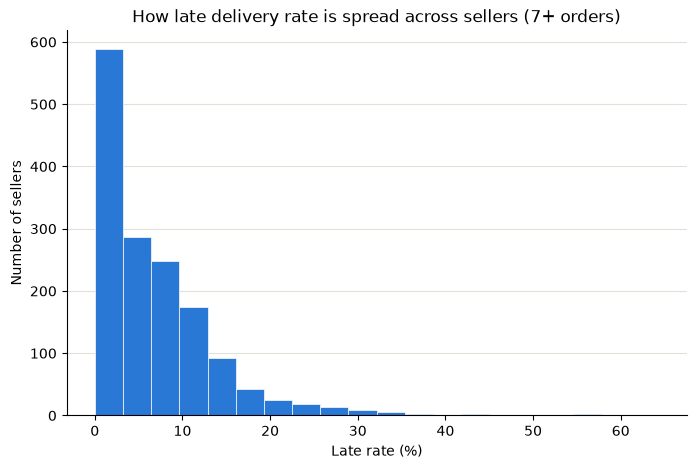

In [23]:
# Histogram: how late rate is distributed across the 1,514 sellers with
# enough order volume to be included in the risk ranking
import matplotlib.pyplot as plt

df = con.sql("SELECT late_rate_pct FROM seller_risk_ranked").df()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["late_rate_pct"], bins=20, color="#2a78d6", edgecolor="#fcfcfb", linewidth=0.5)
ax.set_xlabel("Late rate (%)")
ax.set_ylabel("Number of sellers")
ax.set_title("How late delivery rate is spread across sellers (7+ orders)")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Late rate is heavily skewed toward reliable sellers

Most sellers with enough order history sit well under 10% late rate, and the distribution drops
off fast from there. Only a thin tail stretches out past 30%, up to the worst case around 64%.

This is a good sign for the risk framing of this project. Chronic lateness isn't spread evenly
across sellers, it's concentrated in a small minority who stand out clearly from the rest. The
sellers in that tail from the earlier ranking are genuine outliers, not just the unlucky end of
a wide, even spread.

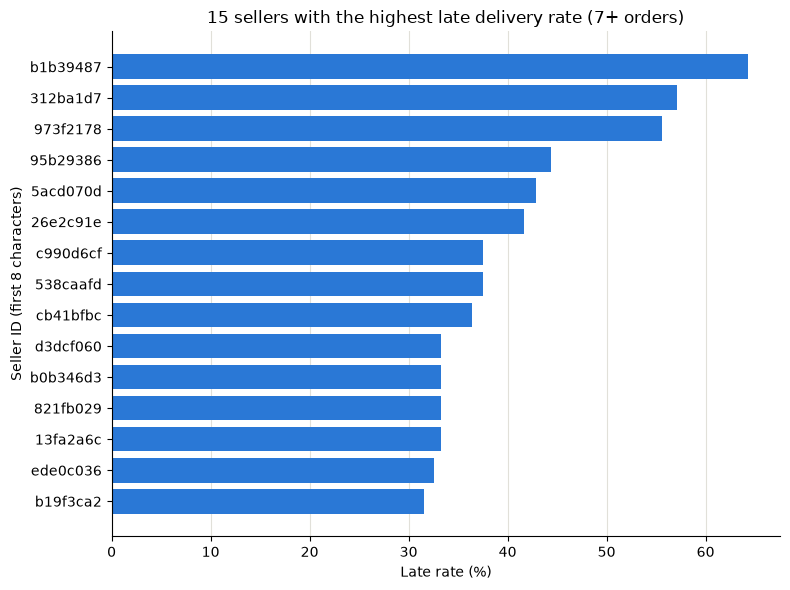

In [25]:
# Horizontal bar chart: the 15 sellers with the highest late rate (7+ orders)
top15 = con.sql("""
    SELECT seller_id, late_rate_pct, total_orders
    FROM seller_risk_ranked
    ORDER BY late_rate_pct DESC
    LIMIT 15
""").df()

top15["seller_id"] = top15["seller_id"].str[:8]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["seller_id"], top15["late_rate_pct"], color="#2a78d6")
ax.invert_yaxis()
ax.set_xlabel("Late rate (%)")
ax.set_ylabel("Seller ID (first 8 characters)")
ax.set_title("15 sellers with the highest late delivery rate (7+ orders)")
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()